Frequency
-------------------------
Intuition
-------------
1.Frequency = how fast a signal repeats

2.Low frequency → slow oscillation (bass)

3.High frequency → fast oscillation (treble)

Nyquist Theorem
----------------------------------
It says:

---->fs ≥ 2 × fmax    
       
Where:
---->fmax = highest frequency in signal

---->fs = sampling rate

Mathematical sine formula:
----------------------------
--->𝑥(𝑡) = sin(2𝜋𝑓𝑡)

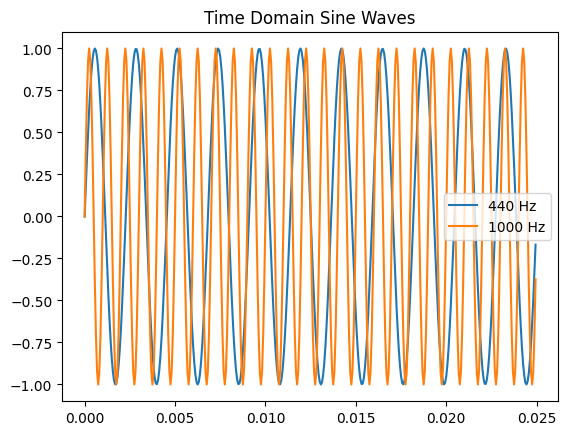

In [9]:
import numpy as np
import matplotlib.pyplot as plt

fs = 16000            # sampling rate
# linspace-->It creates evenly spaced values.
t = np.linspace(0, 1, fs)    # np.linspace(start, stop, number_of_points) ---> So,it Creates 16000 time values between 0 and 1 second.

sine_440 = np.sin(2 * np.pi * 440 * t)
sine_1000 = np.sin(2 * np.pi * 1000 * t)

plt.plot(t[:400], sine_440[:400], label="440 Hz")
plt.plot(t[:400], sine_1000[:400], label="1000 Hz")
plt.legend()
plt.title("Time Domain Sine Waves")
plt.show()

Sampling (why audio has sample rate)
------------------------------------------------------
Intuition

Sampling = converting continuous sound → discrete numbers

Rule: Sampling Rate ≥ 2 × max frequency (Nyquist theorem)

What you learn
---------------------

Undersampling causes aliasing

High frequencies look like low frequencies

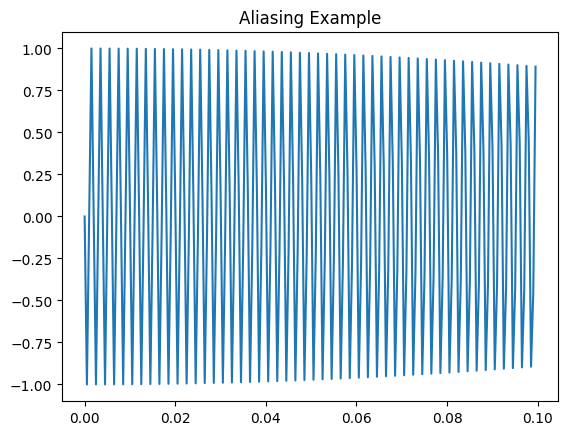

In [15]:
fs_low = 2000
t_low = np.linspace(0, 1, fs_low)
alias_wave = np.sin(2 * np.pi * 1500 * t_low)

plt.plot(t_low[:200], alias_wave[:200])
plt.title("Aliasing Example") # aliasing-->It creates a false frequency.
plt.show()

What is mono
-------------------------
Mono = Monophonic sound

It has:

1.One channel

2.Same sound comes from all speakers

3.Single waveform

🎵 Example:

--->Old radio
--->Phone call
--->Single microphone recording

What is stereo:
-------------------------
Stereo = Two-channel sound

It has:

1.Two channels (Left & Right)

2.Different sound in each speaker

3. 2 waveforms

🎵 Example:

--->Music songs
--->Movies
--->Headphones
--->Surround effects

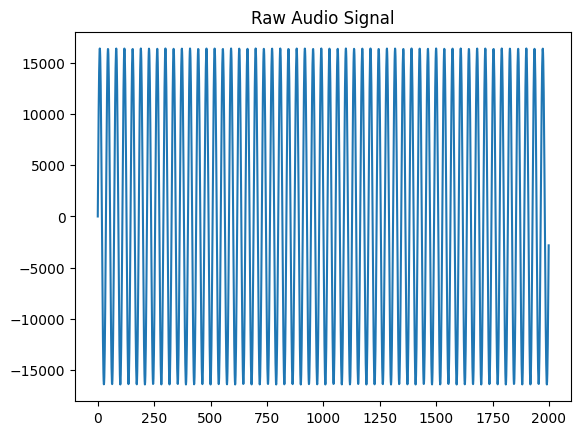

In [44]:
# wavfile → Module used to read/write .wav audio files
from scipy.io import wavfile    
fs, audio = wavfile.read(r"C:\Users\pavan\Downloads\sample_audio.wav")
audio = audio.astype(float)
plt.plot(audio[:2000])
plt.title("Raw Audio Signal")
plt.show()

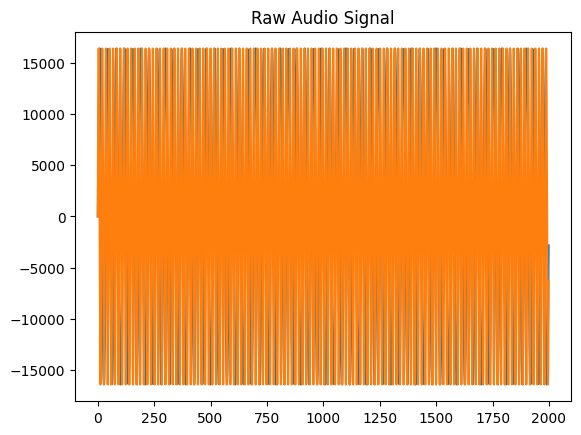

In [39]:
from scipy.io import wavfile
fs, audio = wavfile.read(r"C:\Users\pavan\Downloads\stereo_sample_audio.wav")
audio = audio.astype(float)
plt.plot(audio[:2000])
plt.title("Raw Audio Signal")
plt.show()

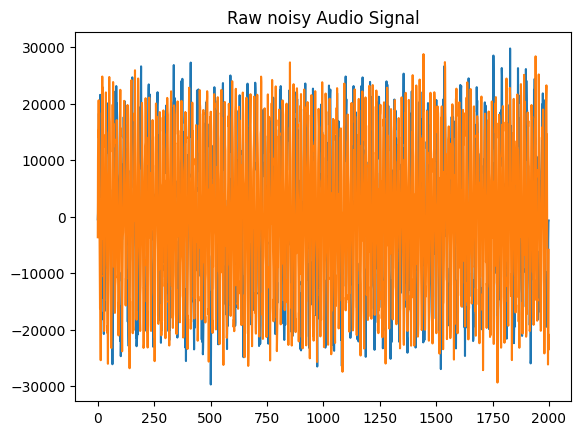

In [45]:
from scipy.io import wavfile
fs, audio = wavfile.read(r"C:\Users\pavan\Downloads\stereo_noisy_audio.wav")
audio = audio.astype(float)
plt.plot(audio[:2000])
plt.title("Raw noisy Audio Signal")
plt.show()

Converting Stereo-->Mono 
------------------------------

In [43]:
import numpy as np
from scipy.io import wavfile

#  Load stereo file
fs, audio = wavfile.read("stereo_audio.wav")

print("Original shape:", audio.shape)   # Should be (N, 2)

#  Convert stereo → mono
mono = np.mean(audio, axis=1)

print("After conversion shape:", mono.shape)   # Should be (N,)

#  Convert back to int16 (if needed)
mono = mono.astype(np.int16)

# Save mono file
wavfile.write("converted_mono.wav", fs, mono)

print("Stereo converted to Mono successfully!")


Original shape: (16000, 2)
After conversion shape: (16000,)
Stereo converted to Mono successfully!


Graphical Show:
--------------------

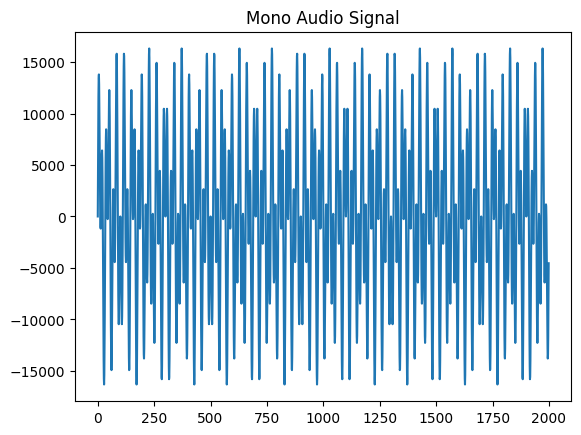

In [53]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt

# Read stereo file
fs, audio = wavfile.read(r"C:\Users\pavan\Downloads\stereo_sample_audio.wav")

# Convert to float
audio = audio.astype(float)

# Convert Stereo to Mono
if len(audio.shape) == 2:      # Check if stereo
    audio = np.mean(audio, axis=1)

# Plot first 2000 samples
plt.plot(audio[:2000])
plt.title("Mono Audio Signal")
plt.show()


How to save the mono file back as .wav
----------------------------------------------

In [58]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt

# Read stereo file
fs, audio = wavfile.read(r"C:\Users\pavan\Downloads\stereo_sample_audio.wav")

# Convert to float
audio = audio.astype(float)

# Convert Stereo → Mono
if len(audio.shape) == 2:
    audio = np.mean(audio, axis=1)

# Normalize (very important before saving)
audio = audio / np.max(np.abs(audio))

# Convert back to int16 (WAV standard format)
audio_int16 = np.int16(audio * 32767)

# Save mono file
#wavfile.write(filename, sample_rate, data)
wavfile.write(r"C:\Users\pavan\Downloads\mono_output.wav", fs, audio_int16)

print("Mono file saved successfully!")


Mono file saved successfully!


Fourier Transform (Time → Frequency)
-----------------------------------------------
Intuition

FFT answers: Which frequencies exist & how strong?

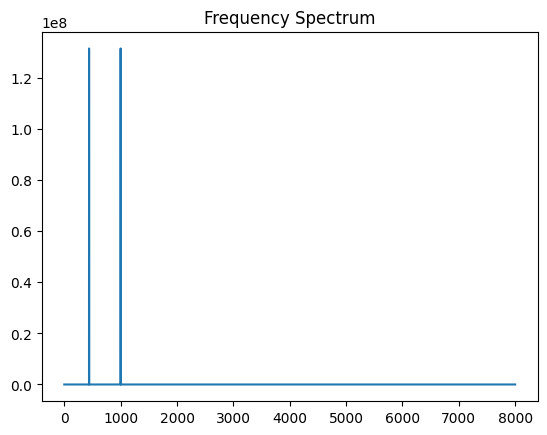

In [5]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt
# Read audio file
fs, audio = wavfile.read(r"C:\Users\pavan\Downloads\mono_output.wav")

# Apply FFT
fft = np.fft.fft(audio)  #It converts time domain signal into frequency domain representation and it returns a complex number array.

#Generate Frequency Axis
freqs = np.fft.fftfreq(len(fft), 1/fs)  # How much time between samples 

# Plot Only Positive Frequencies
plt.plot(freqs[:len(freqs)//2], np.abs(fft[:len(fft)//2]))  # FFT values are complex numbers. So,np.abs() calculates magnitude.
plt.title("Frequency Spectrum")
plt.show()

Windowing (WHY Hamming exists)
-------------------------------
Problem-->

FFT assumes signal repeats → causes spectral leakage

So when FFT repeats it:

|------frame------||------frame------|

A sudden jump occurs at boundaries → this creates artificial high frequencies.

This unwanted spreading of energy is called Spectral Leakage

Solution:

Apply window before FFT

What Windowing Does:
---------------------
Instead of cutting signal abruptly, we multiply it with a smooth curve.

General Formula--> windowed_signal = signal × window_function

1.This makes edges go gradually toward zero.

So when FFT repeats it: No sharp jump and leakage reduces


Hamming Window
--------------
A Hamming window is a smooth curve multiplied with a signal to reduce spectral leakage before applying FFT.

Hamming formula: w(n)=0.54−0.46cos(N−1/2πn)

what it does:

1.Smooth curve

2.Edges not exactly zero

3.Reduces leakage significantly

If original signal-->|----------------|

Hamming makes it-->/\^^^^^^^^^^/\

So:

1.Edges fade

2.Discontinuity reduces

3.Leakage reduces

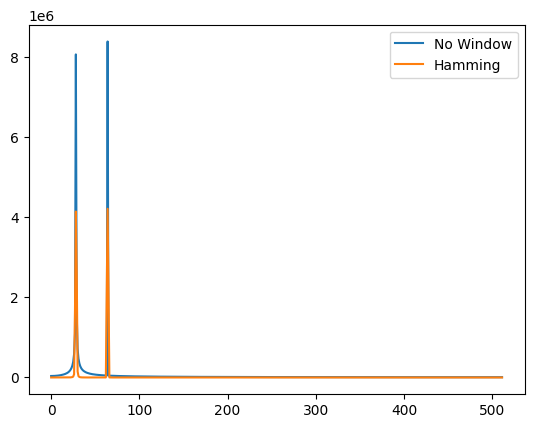

In [4]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt

# Read audio file
fs, audio = wavfile.read(r"C:\Users\pavan\Downloads\mono_output.wav")

frame = audio[:1024]

rect = frame
hamming = frame * np.hamming(1024)

fft_rect = np.abs(np.fft.fft(rect))
fft_ham = np.abs(np.fft.fft(hamming))

plt.plot(fft_rect[:512], label="No Window")
plt.plot(fft_ham[:512], label="Hamming")
plt.legend()
plt.show()


Filtering (Manual):
----------------------

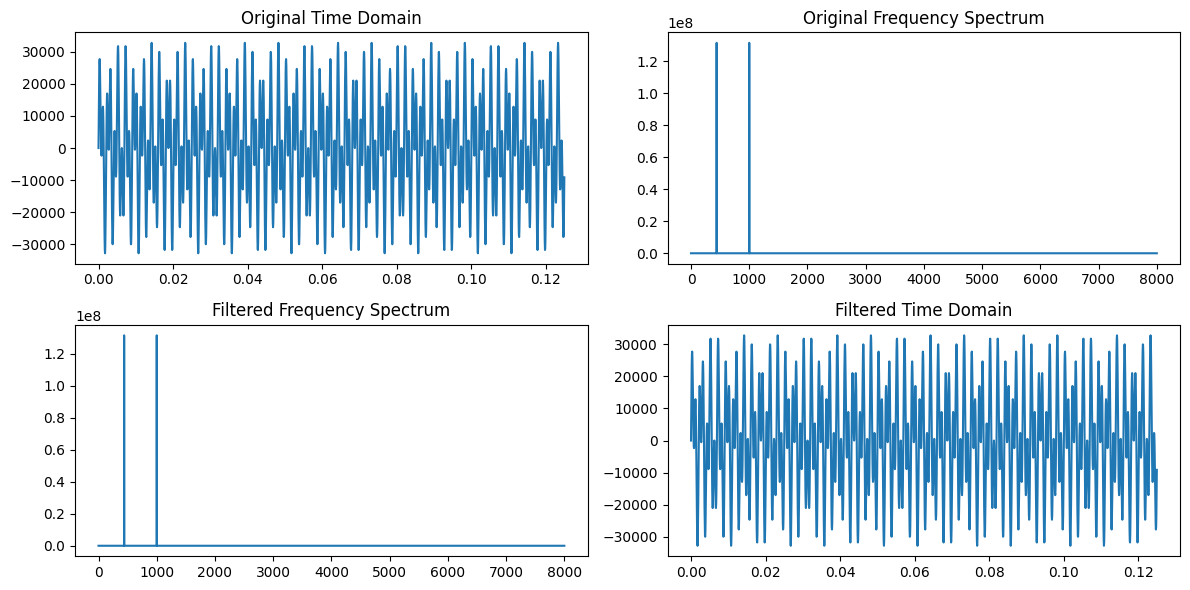

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Read audio file
fs, audio = wavfile.read(r"C:\Users\pavan\Downloads\mono_output.wav")

fft = np.fft.fft(audio)
freqs = np.fft.fftfreq(len(fft), 1/fs)

# Remove High Frequencies
fft[freqs > 3000] = 0
fft[freqs < -3000] = 0

# Converts frequency domain → time domain
filtered = np.fft.ifft(fft).real

# Create time axis
time = np.arange(len(audio)) / fs

plt.figure(figsize=(12,6))

# Original Time Domain
plt.subplot(2,2,1)
plt.plot(time[:2000], audio[:2000])
plt.title("Original Time Domain")

# Original Frequency Spectrum
plt.subplot(2,2,2)
plt.plot(freqs[:len(freqs)//2],
         np.abs(np.fft.fft(audio))[:len(freqs)//2])
plt.title("Original Frequency Spectrum")

# Filtered Frequency Spectrum
plt.subplot(2,2,3)
plt.plot(freqs[:len(freqs)//2],
         np.abs(fft[:len(freqs)//2]))
plt.title("Filtered Frequency Spectrum")

# Filtered Time Domain
plt.subplot(2,2,4)
plt.plot(time[:2000], filtered[:2000])
plt.title("Filtered Time Domain")

plt.tight_layout()
plt.show()



What is a Spectrogram?
-------------------------
A spectrogram shows:

X-axis → Time

Y-axis → Frequency

Color → Energy (Amplitude strength)

General syntax:
------------------
--->plt.specgram(signal, NFFT, Fs, noverlap)

1. Overlap improves smoothness and accuracy.

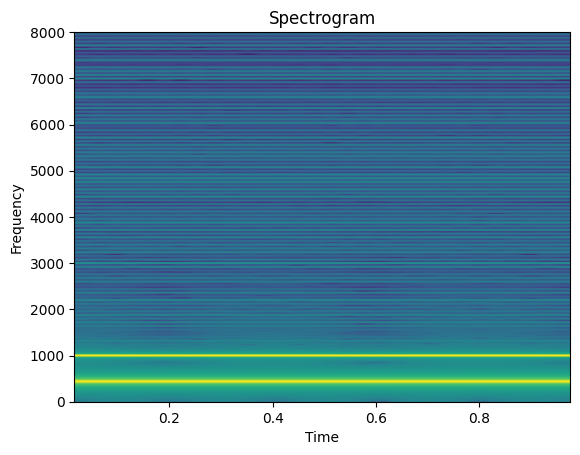

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Read audio file
fs, audio = wavfile.read(r"C:\Users\pavan\Downloads\mono_output.wav")

plt.specgram(audio, NFFT=1024, Fs=fs, noverlap=512)   # noverlap-->Next window overlaps previous window by 512 samples.
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.title("Spectrogram")
plt.show()


Mel Scale (Human Hearing)
-----------------------------
Why Mel Scale?

1.Humans do not hear frequencies linearly.

2.The difference between 100 Hz and 200 Hz sounds BIG.

3.The difference between 7100 Hz and 7200 Hz sounds very SMALL.

That means:

Our hearing is logarithmic, not linear.

To model this behavior mathematically, we use the Mel scale.

The Mel scale converts:
--------------------------------
Hertz (Hz) → how machines measure frequency

Mel → how humans perceive frequency

Formula Used:

mel=2595.log10(1+ℎ𝑧/700)

hz=700⋅(10**2595/mel−1)

Why convert Hz → Mel?
---------------------
Because computers measure sound in Hertz (linear scale), but humans hear sound logarithmically.
So we convert to Mel scale to make machine learning models process sound the way humans perceive it (used in speech recognition, MFCC, voice assistants, etc.).

Why convert Mel → Hz?
------------------------
After processing in Mel scale, we convert back to Hertz to relate results to real physical frequencies or reconstruct audio signals.


In [2]:
import numpy as np

def hz_to_mel(hz):
    return 2595 * np.log10(1 + hz/700)

def mel_to_hz(mel):
    return 700 * (10**(mel/2595) - 1)

mel_value = hz_to_mel(16000)
hz_value = mel_to_hz(mel_value)
print(mel_value)
print(hz_value)

3574.919828790982
15999.999999999998


Purpose of Mel Filterbanks (Manual)
-------------------------------------
how the human ear splits sound frequencies into perceptual bands.

Mel filterbanks:
--------------------
1.Focus more on speech-important low frequencies

2.Compress high frequencies

3.Reduce dimensionality

4.Make features human-like

In [5]:
def mel_filterbank(num_filters, nfft, fs):
    
    # Convert lowest frequency (0 Hz) to Mel scale
    mel_min = hz_to_mel(0)
    
    # Convert highest frequency (Nyquist = fs/2) to Mel scale
    mel_max = hz_to_mel(fs/2)

    # Create evenly spaced Mel points (num_filters + 2 for triangle edges)
    mel_points = np.linspace(mel_min, mel_max, num_filters + 2)  # Why +2?--->each triangle needs left edge,center,right edge

    # Convert Mel points back to Hz
    hz_points = mel_to_hz(mel_points)

    # Convert Hz frequencies to FFT bin numbers
    bins = np.floor((nfft + 1) * hz_points / fs).astype(int)

    # Create empty filterbank matrix
    # Rows = number of filters
    # Columns = number of FFT frequency bins (only positive half)
    fbanks = np.zeros((num_filters, nfft // 2 + 1))

    # Create triangular filters
    for i in range(1, num_filters + 1):

        # Left side of triangle (rising slope)-->rising slope
        for j in range(bins[i - 1], bins[i]):
            fbanks[i - 1, j] = (j - bins[i - 1]) / (bins[i] - bins[i - 1])

        # Right side of triangle (falling slope)--> falling slope
        for j in range(bins[i], bins[i + 1]):
            fbanks[i - 1, j] = (bins[i + 1] - j) / (bins[i + 1] - bins[i])

    return fbanks

mel_filter = mel_filterbank(26, 512, 16000)
print(mel_filter)  #Each row is one triangular filter.

[[0.   0.5  1.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.08 0.04 0.  ]]


Purpose of this Log-Mel Energy
---------------------------------
This code converts raw audio into perceptually meaningful frequency energy features for machine learning.

----->Without Log-Mel:

1.Model won’t match human hearing pattern.

Mel Energy:
 [5.88473028e+01 6.56474229e+01 7.78044062e+01 9.28145019e+01
 1.19543619e+02 1.82496322e+02 3.04540943e+02 8.92539350e+02
 4.84250358e+04 5.08896573e+04 6.79991036e+02 1.68280162e+02
 6.85423257e+01 3.44946203e+01 1.98633168e+01 1.19461330e+01
 7.91191584e+00 5.33364227e+00 3.81273843e+00 2.73514906e+00
 2.06293961e+00 1.63015013e+00 1.34269393e+00 1.14784175e+00
 1.02733938e+00 9.96628523e-01]

Log Mel Energy:
 [ 4.07494600e+00  4.18429834e+00  4.35419806e+00  4.53060290e+00
  4.78368132e+00  5.20673002e+00  5.71880554e+00  6.79407060e+00
  1.07877722e+01  1.08374150e+01  6.52207962e+00  5.12563022e+00
  4.22745145e+00  3.54080338e+00  2.98887465e+00  2.48040763e+00
  2.06836996e+00  1.67403436e+00  1.33834768e+00  1.00618594e+00
  7.24131960e-01  4.88672117e-01  2.94677995e-01  1.37883436e-01
  2.69723337e-02 -3.37717277e-03]


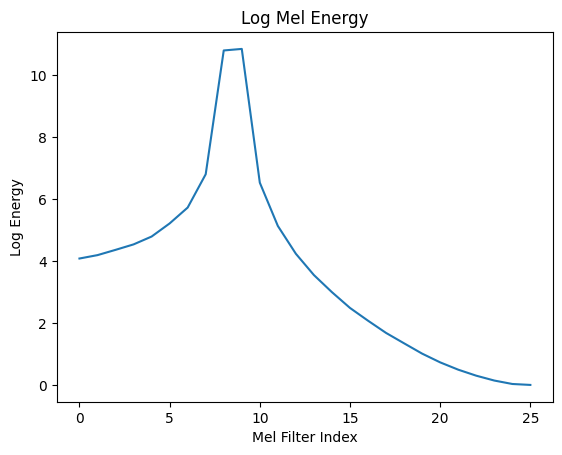

In [7]:
import numpy as np
import matplotlib.pyplot as plt

fs = 16000
nfft = 1024

# Dummy signal (1 frame of sine wave)
t = np.linspace(0, 0.025, 400)
frame = np.sin(2 * np.pi * 1000 * t)

# FFT power spectrum
spectrum = np.abs(np.fft.rfft(frame, nfft)) ** 2
# Mel filterbank
mel_fb = mel_filterbank(26, nfft, fs)

# Mel energy
mel_energy = np.dot(mel_fb, spectrum)
# Log-Mel
log_mel = np.log(mel_energy + 1e-10)

print("Mel Energy:\n", mel_energy)
print("\nLog Mel Energy:\n", log_mel)

# Plot
plt.plot(log_mel)
plt.title("Log Mel Energy")
plt.xlabel("Mel Filter Index")
plt.ylabel("Log Energy")
plt.show()

DCT → MFCCs (No library magic)
-----------------------------------
--->from scipy.fftpack import dct

1.This imports the Discrete Cosine Transform (DCT) function.

2.DCT is similar to FFT but:

3.Uses only cosine waves

4.Produces real values (no imaginary part)

5.Used for compression & decorrelation

**It is commonly used in:

MFCC

JPEG image compression

Signal processing

Log Mel Shape: (26,)
MFCC Shape: (13,)

MFCC Coefficients:
 [18.41798512 11.0641281  -5.618461   -5.78455545 -1.63131982  2.50851252
  3.06640659  0.5530001  -1.91984133 -2.05315585 -0.19455298  1.48117369
  1.38613396]


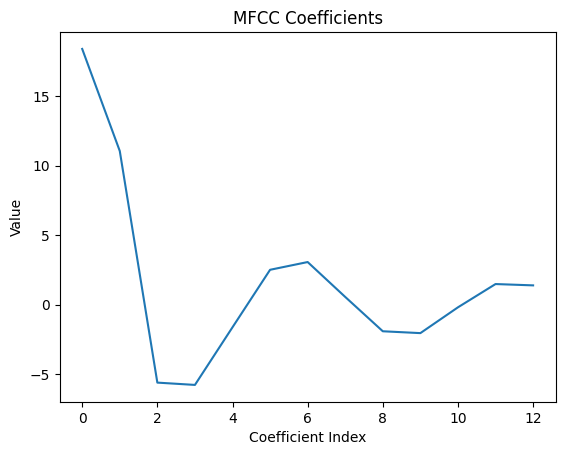

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct

fs = 16000
nfft = 1024

# Create dummy signal (1 kHz sine wave)
t = np.linspace(0, 0.025, 400)
frame = np.sin(2 * np.pi * 1000 * t)

# FFT → Power Spectrum
spectrum = np.abs(np.fft.rfft(frame, nfft)) ** 2

# Mel Filterbank
mel_fb = mel_filterbank(26, nfft, fs)

# Mel Energy
mel_energy = np.dot(mel_fb, spectrum)

# Log-Mel
log_mel = np.log(mel_energy + 1e-10)

# DCT → MFCC
mfcc = dct(log_mel, type=2, norm='ortho')[:13]   # Type-II DCT is the standard used in MFCC.

print("Log Mel Shape:", log_mel.shape)
print("MFCC Shape:", mfcc.shape)
print("\nMFCC Coefficients:\n", mfcc)

plt.plot(mfcc)
plt.title("MFCC Coefficients")
plt.xlabel("Coefficient Index")
plt.ylabel("Value")
plt.show()